In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv("marketing_campaign.csv", sep="\t")

print(data.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [4]:
print(data.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [5]:
data = data.dropna()

print(data.shape)

(2216, 29)


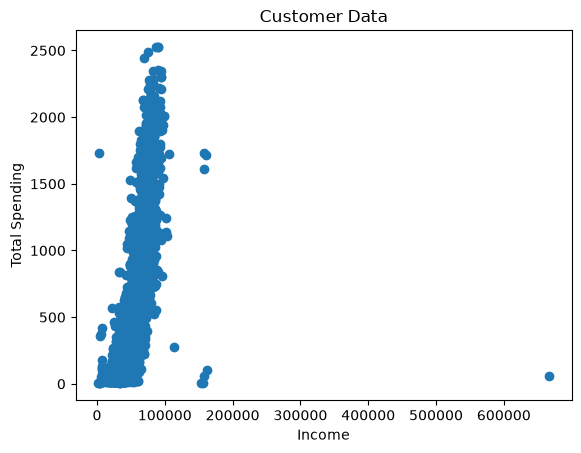

In [6]:
data["Total_Spending"] = (
      data["MntWines"]
    + data["MntFruits"]
    + data["MntMeatProducts"]
    + data["MntFishProducts"]
    + data["MntSweetProducts"]
    + data["MntGoldProds"]
)

plt.scatter(data["Income"], data["Total_Spending"])
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Data")
plt.show()

In [7]:
cols_to_scale = ["Income", "Total_Spending"]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data[cols_to_scale])

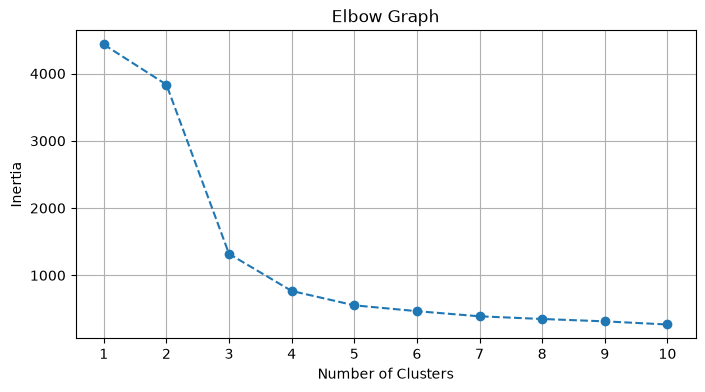

Data Information
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  AcceptedCmp4  AcceptedCmp5  \
0  04-09-2012       58       635  ...             0             0   
1  08-03-2014       38        11  ...             0             0   
2  21-08-2013       26       426  ...             0             0   
3  10-02-2014       26        11  ...             0             0   
4  19-01-2014       94       173  ...             0             0   

   AcceptedCmp1  AcceptedCmp2  Complain  Z_CostContact  Z_Revenue  Response  \
0             0     

In [12]:
k_range = range(1, 11)

interias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    interias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, interias, marker='o', linestyle='--')

plt.title("Elbow Graph")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True)
plt.show()

k = 3      # Choose based on elbow graph

final_km = KMeans(n_clusters=k, random_state=42)

cluster = final_km.fit_predict(scaled_data)

data["Cluster"] = cluster

print('Data Information')

print(data.head())

print('Cluster Centers')

print(final_km.cluster_centers_)



In [11]:


cluster0 = data[data.Cluster == 0]
cluster1 = data[data.Cluster == 1]
cluster2 = data[data.Cluster == 2]

print('Cluster 0')
print(cluster0)
print('Cluster 1')
print(cluster1)
print('Cluster 2')
print(cluster2)


print('Customer in Clusters')

print(data["Cluster"].value_counts())

Cluster 0
         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
1      2174        1954  Graduation         Single  46344.0        1   
3      6182        1984  Graduation       Together  26646.0        1   
7      6177        1985         PhD        Married  33454.0        1   
8      4855        1974         PhD       Together  30351.0        1   
9      5899        1950         PhD       Together   5648.0        1   
...     ...         ...         ...            ...      ...      ...   
2229  10084        1972  Graduation        Married  24434.0        2   
2230   7004        1984  Graduation         Single  11012.0        1   
2232   8080        1986  Graduation         Single  26816.0        0   
2234   8372        1974  Graduation        Married  34421.0        1   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  AcceptedCmp4  \
1            1  08-03-2014       38        11  ...       

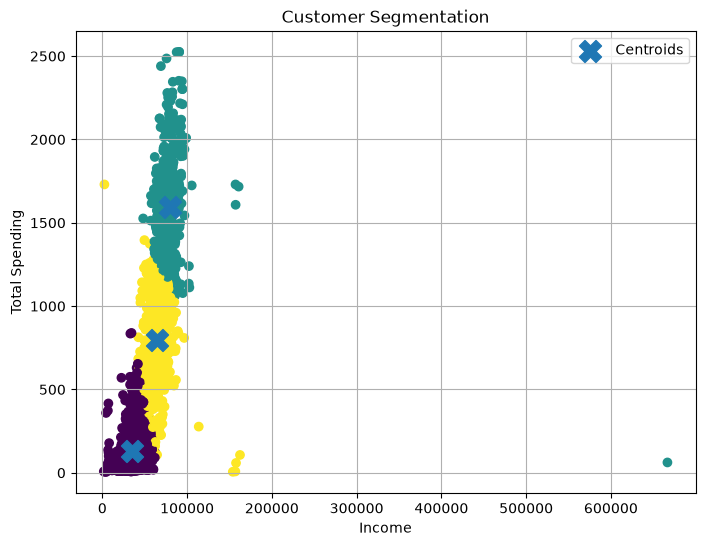

In [9]:
centroids = scaler.inverse_transform(final_km.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    data["Income"],
    data["Total_Spending"],
    c=cluster,
    cmap="viridis"
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=250,
    label='Centroids'
)
    
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
cluster_summary = data.groupby("Cluster").agg({
    "Income": "mean",
    "Total_Spending": "mean"
}).round(2)

cluster_summary["Customer_Count"] = data["Cluster"].value_counts().sort_index()

print(cluster_summary)

           Income  Total_Spending  Customer_Count
Cluster                                          
0        34965.90          129.32            1135
1        79950.15         1593.64             425
2        64199.39          794.52             656


In [20]:
score = silhouette_score(scaled_data, cluster)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.51
